# Housing Market Features

**Purpose.** Examine the definition, provenance, transformation, grain, joined
completeness, distribution, outliers, redundancy, temporal alignment, retention
decision, and infographic use of the domain features.

This notebook is a diagnostic consumer of the `feature.*` semantic marts. Database
construction owns every feature transformation.

## Setup and authoritative feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "quoll.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
con = duckdb.connect(str(ROOT / "data" / "quoll.duckdb"), read_only=True)
FEATURE_TABLES = ['county_housing_monthly']
EXCLUDED_CATALOG_FEATURES = []
TABLE_NAMES = ", ".join("?" for _ in FEATURE_TABLES)

catalog = con.execute(
    f"SELECT * FROM feature.catalog "
    f"WHERE feature_table IN ({TABLE_NAMES}) "
    f"OR (feature_table IS NULL AND lower(category) = lower(?))"
    f"ORDER BY retained DESC, feature_table, feature_name",
    [*FEATURE_TABLES, 'Housing Market'],
).df()
catalog = catalog.loc[
    ~catalog["feature_name"].isin(EXCLUDED_CATALOG_FEATURES)
].copy()
display(catalog)

,geographic_grain,retained,exclusion_reason,feature_table,feature_name,category,definition,unit,source_tables,transformation,temporal_grain,infographic_use
0,county,True,None,county_housing_monthly,avg_sale_to_list_yoy,Housing market,Year-over-year change in average sale-to-list ...,proportion,mart.redfin_county_monthly,Redfin text value parsed to numeric.,monthly,Event-window metric
1,county,True,None,county_housing_monthly,homes_sold_yoy,Housing market,Year-over-year change in homes sold.,proportion,mart.redfin_county_monthly,Redfin text value parsed to numeric.,monthly,Event-window metric
2,county,True,None,county_housing_monthly,housing_market_index,Housing market,Composite standardized housing-market movement...,z-score,mart.redfin_county_monthly,"Mean of global z-scores for PPSF YOY, sale-to-...",monthly,Event-window supporting outcome
3,county,True,None,county_housing_monthly,inventory_yoy,Housing market,Year-over-year change in active inventory.,proportion,mart.redfin_county_monthly,Redfin text value parsed to numeric.,monthly,Event-window metric
4,county,True,None,county_housing_monthly,median_dom_yoy,Housing market,Year-over-year change in median days on market.,days,mart.redfin_county_monthly,Redfin text value parsed to numeric.,monthly,Event-window metric
5,county,True,None,county_housing_monthly,median_ppsf_yoy,Housing market,Year-over-year change in median sale price per...,proportion,mart.redfin_county_monthly,Redfin text value parsed to numeric for All Re...,monthly,Primary housing outcome
6,county,True,None,county_housing_monthly,new_listings_yoy,Housing market,Year-over-year change in new listings.,proportion,mart.redfin_county_monthly,Redfin text value parsed to numeric.,monthly,Event-window metric
7,county,False,Removed from county-relative PPSF model features.,county_housing_monthly,price_drops_yoy,Housing market,Year-over-year change in share of listings wit...,proportion,mart.redfin_county_monthly,Redfin text value parsed to numeric.,monthly,Event-window metric
8,county,False,Excluded from feature ranking because it dupli...,None,median_ppsf_yoy_ten_year_average,Housing market,Ten-year average of the primary PPSF YOY outcome.,proportion,mart.redfin_county_monthly,Average across months and years.,ten-year county summary,None


The catalog above is the answer key for definition, unit, source, transformation,
grain, retention/exclusion, and infographic use. The remaining sections test whether
the built data match those definitions.

## Geographic and temporal grain

In [2]:
inventory_rows = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    time_sql = (
        f"min({time_column}) AS min_time, max({time_column}) AS max_time, "
        f"count(DISTINCT {time_column}) AS periods"
        if time_column else
        "NULL AS min_time, NULL AS max_time, NULL AS periods"
    )
    row = con.execute(
        f"SELECT count(*) AS rows, count(DISTINCT fips) AS counties, {time_sql} "
        f"FROM feature.{table}"
    ).df()
    row.insert(0, "feature_table", table)
    inventory_rows.append(row)
inventory = pd.concat(inventory_rows, ignore_index=True)
display(inventory)

,feature_table,rows,counties,min_time,max_time,periods
0,county_housing_monthly,444537,3083,2012-01-01,2025-12-01,168


## Completeness after joins

In [3]:
completeness_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    has_year = "year" in schema["column_name"].tolist()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    feature_columns = [
        column for column in numeric_columns
        if column not in {"year", "month"} and not column.endswith("_count")
    ]
    row_count = con.execute(f"SELECT count(*) FROM feature.{table}").fetchone()[0]
    rows = []
    for column in feature_columns:
        if has_year:
            present, first_year, last_year = con.execute(
                f'SELECT count("{column}"), '
                f'min(year) FILTER (WHERE "{column}" IS NOT NULL), '
                f'max(year) FILTER (WHERE "{column}" IS NOT NULL) '
                f"FROM feature.{table}"
            ).fetchone()
            in_scope_rows = con.execute(
                f"SELECT count(*) FROM feature.{table} "
                f"WHERE year BETWEEN ? AND ?",
                [first_year, last_year],
            ).fetchone()[0] if first_year is not None and last_year is not None else 0
        else:
            present = con.execute(
                f'SELECT count("{column}") FROM feature.{table}'
            ).fetchone()[0]
            first_year = last_year = None
            in_scope_rows = row_count
        rows.append({
            "feature_table": table, "feature_name": column,
            "non_null_rows": present, "total_rows": row_count,
            "global_complete_pct": present / row_count * 100 if row_count else np.nan,
            "first_observed_year": first_year,
            "last_observed_year": last_year,
            "in_scope_rows": in_scope_rows,
            "in_scope_complete_pct": (
                present / in_scope_rows * 100 if in_scope_rows else np.nan
            ),
        })
    completeness_frames.append(pd.DataFrame(rows))
completeness = pd.concat(completeness_frames, ignore_index=True)
display(completeness.sort_values(["feature_table", "global_complete_pct"]))

,feature_table,feature_name,non_null_rows,total_rows,global_complete_pct,first_observed_year,last_observed_year,in_scope_rows,in_scope_complete_pct
8,county_housing_monthly,price_drops_yoy,191662,444537,43.114971,None,None,444537,43.114971
3,county_housing_monthly,avg_sale_to_list_yoy,379803,444537,85.437883,None,None,444537,85.437883
6,county_housing_monthly,new_listings_yoy,398820,444537,89.715817,None,None,444537,89.715817
5,county_housing_monthly,inventory_yoy,407809,444537,91.737921,None,None,444537,91.737921
7,county_housing_monthly,median_dom_yoy,410782,444537,92.406706,None,None,444537,92.406706
2,county_housing_monthly,median_ppsf_yoy,412480,444537,92.788677,None,None,444537,92.788677
4,county_housing_monthly,homes_sold_yoy,413718,444537,93.067169,None,None,444537,93.067169
9,county_housing_monthly,housing_market_index,413962,444537,93.122057,None,None,444537,93.122057
1,county_housing_monthly,median_ppsf_usd,443296,444537,99.720833,None,None,444537,99.720833
0,county_housing_monthly,median_sale_price_usd,444260,444537,99.937688,None,None,444537,99.937688


## Distributions, outliers, and implausible values

In [4]:
frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    numeric_columns = [
        c for c in numeric_columns
        if c not in {"year", "month"} and not c.endswith("_count")
    ]
    if not numeric_columns:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    description = frame.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.reset_index(
        names="feature_name"
    )
    description.insert(0, "feature_table", table)
    q1 = frame.quantile(0.25)
    q3 = frame.quantile(0.75)
    iqr = q3 - q1
    outlier_counts = ((frame.lt(q1 - 1.5 * iqr)) | (frame.gt(q3 + 1.5 * iqr))).sum()
    description["iqr_outlier_count"] = description["feature_name"].map(outlier_counts)
    description["review_flag"] = np.where(
        (description["min"] < 0)
        & description["feature_name"].str.contains(
            "income|wage|population|price|value|precipitation|score", case=False
        ),
        "negative value requires review",
        np.where(description["iqr_outlier_count"] > 0, "distribution has IQR outliers", "none"),
    )
    frames.append(description)
distributions = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
display(distributions)

,feature_table,feature_name,count,mean,std,min,1%,25%,50%,75%,99%,max,iqr_outlier_count,review_flag
0,county_housing_monthly,median_sale_price_usd,444260.0,202004.659236,181065.009256,1.000000,25000.000000,114750.000000,165000.000000,248000.000000,735000.000000,3.812700e+07,22414,distribution has IQR outliers
1,county_housing_monthly,median_ppsf_usd,443296.0,122.848132,988.952662,0.000277,17.611684,69.900801,98.482277,141.199470,448.812744,4.962500e+05,22759,distribution has IQR outliers
2,county_housing_monthly,median_ppsf_yoy,412480.0,1.791466,488.187310,-0.999996,-0.643235,-0.028974,0.064963,0.184822,2.362467,2.297084e+05,53367,distribution has IQR outliers
3,county_housing_monthly,avg_sale_to_list_yoy,379803.0,0.002733,0.053271,-1.190726,-0.157600,-0.012744,0.002319,0.018024,0.167018,1.012218e+00,45666,distribution has IQR outliers
4,county_housing_monthly,homes_sold_yoy,413718.0,0.355795,4.502303,-0.993671,-0.750000,-0.161290,0.014388,0.285714,5.000000,8.592500e+02,40552,distribution has IQR outliers
5,county_housing_monthly,inventory_yoy,407809.0,0.097178,0.872749,-0.977778,-0.600000,-0.163077,-0.015152,0.175719,2.400000,1.000000e+02,26861,distribution has IQR outliers
6,county_housing_monthly,new_listings_yoy,398820.0,0.203089,1.250704,-0.985075,-0.714286,-0.156938,0.013699,0.259259,4.000000,1.580000e+02,35309,distribution has IQR outliers
7,county_housing_monthly,median_dom_yoy,410782.0,-7.752871,163.883504,-36539.000000,-334.000000,-27.000000,-4.000000,15.000000,286.000000,3.658700e+04,56170,distribution has IQR outliers
8,county_housing_monthly,price_drops_yoy,191662.0,0.013733,0.094105,-0.933333,-0.237055,-0.030873,0.008961,0.054795,0.283333,9.230769e-01,13207,negative value requires review
9,county_housing_monthly,housing_market_index,413962.0,-0.000494,0.540438,-26.703647,-1.040808,-0.094143,0.012215,0.110330,0.845674,1.568285e+02,38538,distribution has IQR outliers


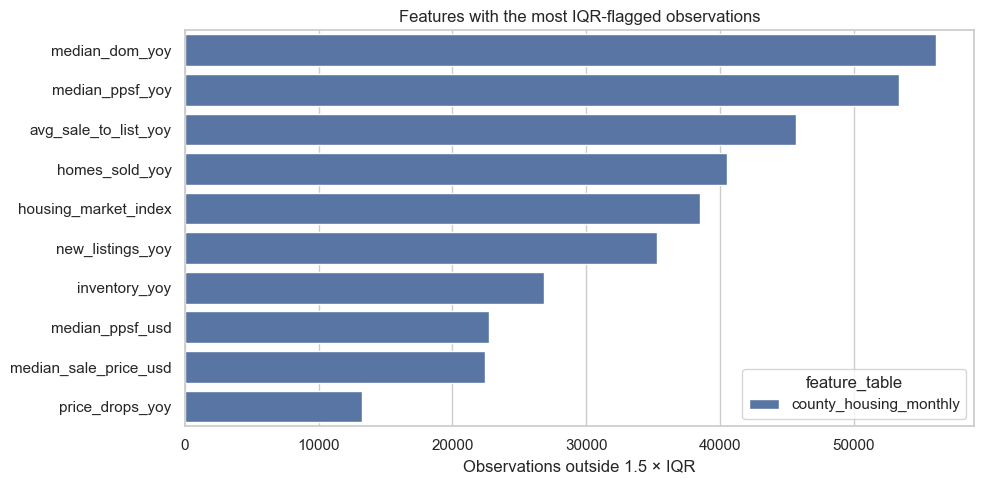

In [5]:
plot_data = distributions.sort_values("iqr_outlier_count", ascending=False).head(12)
if not plot_data.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_data, y="feature_name", x="iqr_outlier_count", hue="feature_table", ax=ax)
    ax.set_title("Features with the most IQR-flagged observations")
    ax.set_xlabel("Observations outside 1.5 × IQR")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## Redundancy among related features

In [6]:
correlation_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL", case=False, regex=True),
        "column_name",
    ].tolist()
    if len(numeric_columns) < 2:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    corr = frame.corr(min_periods=100)
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pairs.insert(0, "feature_table", table)
    correlation_frames.append(pairs)
correlations = pd.concat(correlation_frames, ignore_index=True) if correlation_frames else pd.DataFrame()
if not correlations.empty:
    correlations["absolute_correlation"] = correlations["correlation"].abs()
    display(correlations.sort_values("absolute_correlation", ascending=False).head(30))
else:
    display(pd.DataFrame({"result": ["Fewer than two continuous features were available."]}))

,feature_table,feature_a,feature_b,correlation,absolute_correlation
29,county_housing_monthly,avg_sale_to_list_yoy,housing_market_index,0.669215,0.669215
23,county_housing_monthly,median_ppsf_yoy,housing_market_index,0.622035,0.622035
35,county_housing_monthly,inventory_yoy,new_listings_yoy,0.613575,0.613575
34,county_housing_monthly,homes_sold_yoy,housing_market_index,0.418556,0.418556
38,county_housing_monthly,inventory_yoy,housing_market_index,-0.393634,0.393634
30,county_housing_monthly,homes_sold_yoy,inventory_yoy,0.202223,0.202223
31,county_housing_monthly,homes_sold_yoy,new_listings_yoy,0.202006,0.202006
41,county_housing_monthly,new_listings_yoy,housing_market_index,-0.168055,0.168055
0,county_housing_monthly,median_sale_price_usd,median_ppsf_usd,0.084083,0.084083
40,county_housing_monthly,new_listings_yoy,price_drops_yoy,-0.075049,0.075049


## Temporal alignment

In [7]:
alignment_frames = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    flags = [c for c in columns if c.startswith("has_")]
    if time_column and flags:
        aggregates = ", ".join(
            f'avg(cast("{flag}" AS INTEGER)) * 100 AS "{flag}_pct"' for flag in flags
        )
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties, {aggregates} "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
    elif time_column:
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
alignment = pd.concat(alignment_frames, ignore_index=True) if alignment_frames else pd.DataFrame()
display(alignment)

,feature_table,housing_month,counties
0,county_housing_monthly,2012-01-01,1905
1,county_housing_monthly,2012-02-01,1983
2,county_housing_monthly,2012-03-01,2011
3,county_housing_monthly,2012-04-01,1974
4,county_housing_monthly,2012-05-01,2001
...,...,...,...
163,county_housing_monthly,2025-08-01,2865
164,county_housing_monthly,2025-09-01,2838
165,county_housing_monthly,2025-10-01,2860
166,county_housing_monthly,2025-11-01,2811


## Retention and infographic use

Retention is decided in `feature.catalog`, not from visual inspection in this
notebook. A feature is retained when its definition is interpretable, its unit and
grain are stable, its completeness is adequate for its intended comparison, and it
does not duplicate the outcome or a stronger related measure. The `infographic_use`
and `exclusion_reason` catalog fields record the current decision.

In [8]:
display(catalog[[
    "feature_name", "retained", "exclusion_reason", "infographic_use",
    "source_tables", "transformation"
]])
con.close()

,feature_name,retained,exclusion_reason,infographic_use,source_tables,transformation
0,avg_sale_to_list_yoy,True,None,Event-window metric,mart.redfin_county_monthly,Redfin text value parsed to numeric.
1,homes_sold_yoy,True,None,Event-window metric,mart.redfin_county_monthly,Redfin text value parsed to numeric.
2,housing_market_index,True,None,Event-window supporting outcome,mart.redfin_county_monthly,"Mean of global z-scores for PPSF YOY, sale-to-..."
3,inventory_yoy,True,None,Event-window metric,mart.redfin_county_monthly,Redfin text value parsed to numeric.
4,median_dom_yoy,True,None,Event-window metric,mart.redfin_county_monthly,Redfin text value parsed to numeric.
5,median_ppsf_yoy,True,None,Primary housing outcome,mart.redfin_county_monthly,Redfin text value parsed to numeric for All Re...
6,new_listings_yoy,True,None,Event-window metric,mart.redfin_county_monthly,Redfin text value parsed to numeric.
7,price_drops_yoy,False,Removed from county-relative PPSF model features.,Event-window metric,mart.redfin_county_monthly,Redfin text value parsed to numeric.
8,median_ppsf_yoy_ten_year_average,False,Excluded from feature ranking because it dupli...,None,mart.redfin_county_monthly,Average across months and years.
